# Model Comparison

The data, now treated and cleaned, will be used as a source for the train test split and class imbalance treatment through Synthetic Minority Over-sampling Technique **(SMOTE)** this generates, through mathematical formulas, a mock version of the dataset based on real cases already recorded. This ensures replicability and the possibility of comparison between models without causing possible deviations or misleading results.

## Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## General Function

#### ROC-AUC
The area under the ROC curve (AUC) represents the probability that the model, if given a randomly chosen positive and negative example, would classify the positive as better than the negative. In this function, true positive rate, false positive rate (TPR and FPR) data and auc score are generated as a result of training on balanced and unbalanced data.

In [2]:
def generate_roc_data(model, x_train, y_train, x_test, y_test, use_smote = False, random_state = 36):
    
    # Using Smote if necessary
    if use_smote:
        smt = SMOTE(random_state = random_state)
        x_train, y_train = smt.fit_resample(x_train, y_train)
    
    # Model training
    model.fit(x_train, y_train)
    
    # Calculating probability
    y_proba = model.predict_proba(x_test)[:, 1]
    
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Calculate AUC
    auc = roc_auc_score(y_test, y_proba)
    
    return fpr, tpr, auc

The "compare_roc_auc" function plots the values obtained in the previous function on a graph, comparing their results.

In [3]:
def compare_roc_auc(smote_fpr, smote_tpr, no_smote_fpr, no_smote_tpr, smote_auc, no_smote_auc):
    
    plt.figure(figsize = (5,5), dpi = 100)

    plt.plot(smote_fpr, smote_tpr, marker = '.', label = 'With SMOTE (auc = %0.3f)' % smote_auc)
    plt.plot(no_smote_fpr, no_smote_tpr, marker = '.', label = 'Without SMOTE (auc = %0.3f)' % no_smote_auc)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
    plt.legend()
    plt.show()

#### Confusion Matrix
A confusion matrix (or, error matrix) is a visualization method for classifier algorithm results. More specifically, it is a table that breaks down the number of ground truth instances of a specific class against the number of predicted class instances.

In [4]:
def compare_confusion_matrix(y_test, y_predict_smote, y_predict_no_smote):
    
    cm_smote = confusion_matrix(y_test, y_predict_smote)
    cm_no_smote = confusion_matrix(y_test, y_predict_no_smote)
    
    fig, axes = plt.subplots(1, 2, figsize = (10, 4))
    
    # SMOTE
    sns.heatmap(cm_smote, annot = True, fmt = 'd', cmap = 'Blues', ax = axes[0])
    axes[0].set_title('With SMOTE')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # NO SMOTE
    sns.heatmap(cm_no_smote, annot=True, fmt = 'd', cmap = 'Blues', ax = axes[1])
    axes[1].set_title('Without SMOTE')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

#### Classification report

lorem epsum almdoasbd oaisd flasudfbew uige sdçfohert iausdtfb vsnd iuegrywert yegfawfncvnvl

In [5]:
def compare_classification_report(y_test, y_pred_smote, y_pred_no_smote):
    
    report_smote = classification_report(y_test, y_pred_smote, output_dict = True)
    report_no_smote = classification_report(y_test, y_pred_no_smote, output_dict = True)
    
    df_smote = pd.DataFrame(report_smote).transpose()
    df_no_smote = pd.DataFrame(report_no_smote).transpose()
    
    df_smote['Model'] = 'SMOTE'
    df_no_smote['Model'] = 'NO_SMOTE'
    
    df_combined = pd.concat([df_smote, df_no_smote])
    
    return df_combined

## Opening file

In [6]:
# Open the csv file
Balanced_CCDF = pd.read_parquet('../../data/processed/clean_creditcard.parquet')

In [7]:
# Creating a separation between features and target
x = Balanced_CCDF.drop('Class', axis = 1)
y = Balanced_CCDF['Class']

## Train test split

Spliting the data set into two pieces, a training set and a testing set. This consists of random sampling without replacement about 70 percent of the rows and putting them into the training set. The remaining 30 percent is put into the test set. This allows the evaluation on how well a model generalizes to new, unseen data and also prevent overfitting


In [8]:
# Selecting the percentage of rows that are going to be used as training 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42, stratify = y)

# Random Forest

The random forest algorithm is an extension of the bagging method as it utilizes both bagging and feature randomness to create an uncorrelated forest of decision trees. Feature randomness, also known as feature bagging or “the random subspace method”, generates a random subset of features, which ensures low correlation among decision trees. This is a key difference between decision trees and random forests.

In [9]:
# Selecting Random Forest as the model to train
rf_model_smote = RandomForestClassifier(random_state = 36)
rf_model_no_smote = RandomForestClassifier(random_state = 36)

# Generating TPR and FPR with SMOTE
smote_fpr, smote_tpr, smote_auc = generate_roc_data(rf_model_smote, x_train, y_train, x_test, y_test, use_smote = True)

# Generating predictions based on the trained model (with SMOTE)
y_predict_smote = rf_model_smote.predict(x_test)

# Generating TPR and FPR without SMOTE
no_smote_fpr, no_smote_tpr, no_smote_auc = generate_roc_data(rf_model_no_smote, x_train, y_train, x_test, y_test, use_smote = False)

# Generating predictions based on the trained model (without SMOTE)
y_predict_no_smote = rf_model_no_smote.predict(x_test)

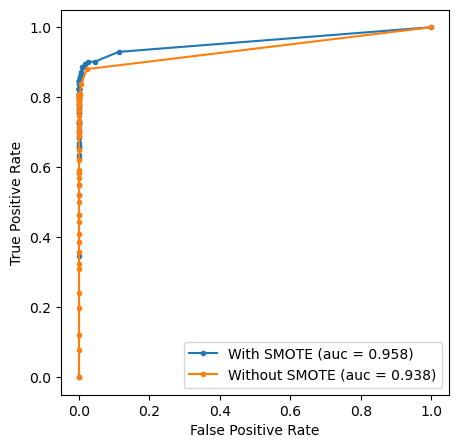

In [10]:
# Plotting the positive rate chart, comparing both results
compare_roc_auc(smote_fpr, smote_tpr,
                no_smote_fpr, no_smote_tpr,
                smote_auc, no_smote_auc)

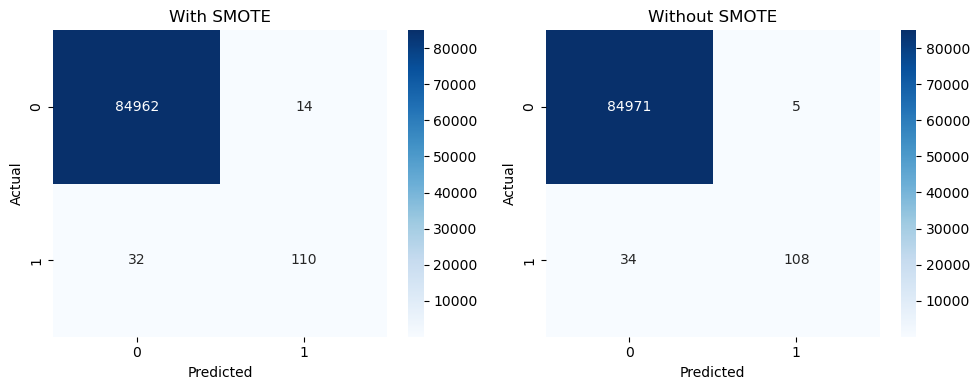

In [11]:
compare_confusion_matrix(y_test, y_predict_smote, y_predict_no_smote)

In [14]:
df_results = compare_classification_report(y_test, y_predict_smote, y_predict_no_smote)

display(df_results[['precision', 'recall', 'f1-score']])

,precision,recall,f1-score
0,0.999624,0.999835,0.999729
1,0.887097,0.774648,0.827068
accuracy,0.999460,0.999460,0.999460
macro avg,0.943360,0.887242,0.913399
weighted avg,0.999436,0.999460,0.999441
0,0.999600,0.999941,0.999771
1,0.955752,0.760563,0.847059
accuracy,0.999542,0.999542,0.999542
macro avg,0.977676,0.880252,0.923415
weighted avg,0.999527,0.999542,0.999516


# Logistic Regression

Logistic regression, like linear regression, is a type of linear model that examines the relationship between predictor variables (independent variables) and an output variable (the response, target or dependent variable). The key difference is that linear regression is used when the output is a continuous value

In [15]:
# Selecting Logistic regression as the model to train
# And normalizing the data with Standard Scaler to prevent performance instability
lr_model_smote = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter = 1000, random_state = 36))])

lr_model_no_smote = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter = 1000, random_state = 36))])

# Generating TPR and FPR with SMOTE
smote_fpr, smote_tpr, smote_auc = generate_roc_data(lr_model_smote, x_train, y_train, x_test, y_test, use_smote = True)

# Generating predictions based on the trained model (with SMOTE)
y_predict_smote = lr_model_smote.predict(x_test)

# Generating TPR and FPR without SMOTE
no_smote_fpr, no_smote_tpr, no_smote_auc = generate_roc_data(lr_model_no_smote, x_train, y_train, x_test, y_test, use_smote = False)

# Generating predictions based on the trained model (without SMOTE)
y_predict_no_smote = lr_model_no_smote.predict(x_test)

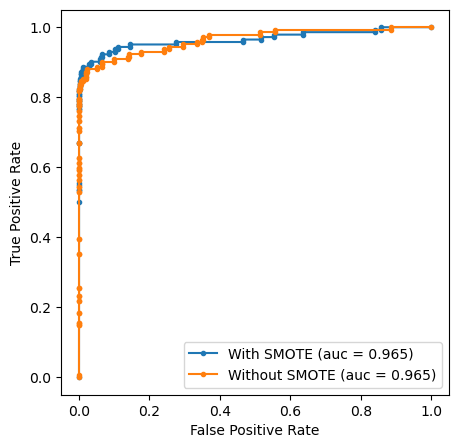

In [16]:
# Plotting the positive rate chart, comparing both results
compare_roc_auc(smote_fpr, smote_tpr,
                no_smote_fpr, no_smote_tpr,
                smote_auc, no_smote_auc)

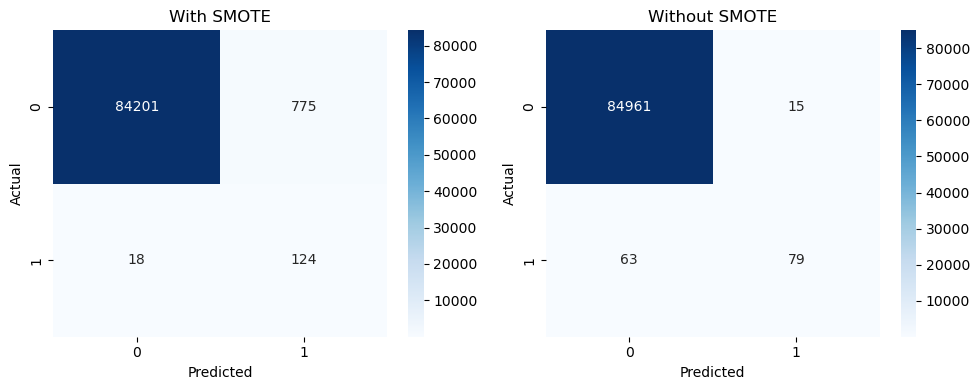

In [17]:
compare_confusion_matrix(y_test, y_predict_smote, y_predict_no_smote)

In [18]:
df_results = compare_classification_report(y_test, y_predict_smote, y_predict_no_smote)

display(df_results[['precision', 'recall', 'f1-score']])

,precision,recall,f1-score
0,0.999786,0.990880,0.995313
1,0.137931,0.873239,0.238232
accuracy,0.990684,0.990684,0.990684
macro avg,0.568859,0.932060,0.616773
weighted avg,0.998348,0.990684,0.994050
0,0.999259,0.999823,0.999541
1,0.840426,0.556338,0.669492
accuracy,0.999084,0.999084,0.999084
macro avg,0.919842,0.778081,0.834516
weighted avg,0.998994,0.999084,0.998991
